theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]
[274.50568018 273.77890685 271.60879971 268.02578541 263.07987412
 256.8396275  249.39075165 240.83435155 231.28489197 220.86791683
 209.71758472 197.97408193 185.78097642 173.28257655 160.62135635
 147.93550619 135.35666244 123.00786358 111.00177272  99.4391979
  88.40793293  77.98193173  68.22082024  59.1697407   50.85951439
  43.3071016   36.51633041  30.47886046  25.17534342  20.5767389
  16.64574293  13.33828559  10.60505564   8.39301195   6.64684476
   5.31035375   4.32771494   3.64461334   3.20922412   2.97303051
   2.89147242   2.924425     3.03651116   3.1972569    3.38110139
   3.56727754   3.73958052   3.88604352   3.99854096   4.07233911
   4.10561389   4.09895425   4.05486814   3.97730589   3.87121363
   3.74212705   3.59581306   3.43796457   3.27395112   3.10862591
   2.9461877    2.79009448   2.64302413   2.50687663   2.38281109
   2.27131102   2.1

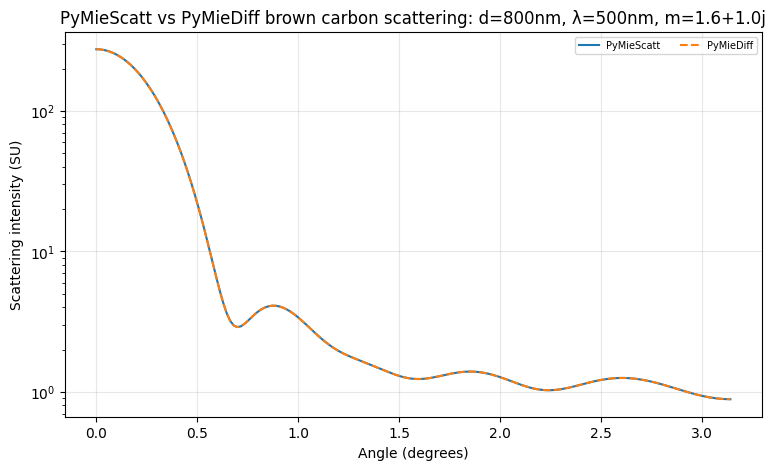

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps
import pymiediff as pmd

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

for i in range(1):
    # Brown carbon at the center of our range
    n = 1.6
    k = 1.0
    wavelength = 500   # nm
    diameter = 800     # nm

    m = complex(n, k)
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter, nMedium=1.0,
        minAngle=0, maxAngle=180, angularResolution=1, angleMeasure='Radians'
    )

    print("theta shape:", theta.shape)
    print("SU shape:", SU.shape)
    print("First few SU values:", SU[:5])

    
print(SU)
print(theta)
# - config
wl0 = torch.tensor([500])
k0 = 2 * torch.pi / wl0

r_core = 800
# r_shell = 100.0
mat_core = pmd.materials.MatDatabase("Si")
mat_shell = pmd.materials.MatDatabase("Ge")
n_env = 1.0

# - setup the particle
p = pmd.Particle(
    r_layers=[400],
    mat_layers=[1.6 + 1.0j],
    mat_env = 1.00
)


theta = torch.arange(0, 181) * torch.pi/180
print("Second Theta")
print(theta)
print(p)
angle_scattering = (p.get_angular_scattering(k0= k0, theta = theta))
print(angle_scattering["i_unpol"])
test_scattering = (angle_scattering["i_unpol"]).numpy()
print(SU)
cs = p.get_cross_sections(k0)
print(angle_scattering["i_unpol"])
print(test_scattering)

plt.figure(figsize=(9, 5))
plt.plot(theta, SU, "-", label = "PyMieScatt")
plt.plot(theta, test_scattering, '--', label = "PyMieDiff")
plt.xlabel("Angle (Radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"PyMieScatt vs PyMieDiff brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=7, ncol=2)
plt.show()